In [1]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [3]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [4]:
df.shape

(100, 3)

In [5]:
df.head()

,feature1,feature2,target
0,1.725222,-1.364638,-21.742360
1,-0.172330,-0.283308,-23.349812
2,0.974868,1.570948,93.893880
3,-1.592785,0.192106,-80.801732
4,-0.317753,-0.043030,-6.950915


In [24]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# ax.scatter(df['feature1'], df['feature2'], df['target'])

# ax.set_xlabel('feature1')
# ax.set_ylabel('feature2')
# ax.set_zlabel('target')

# plt.show()

In [25]:
# fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

# fig.show()
# not working so upper  and lower

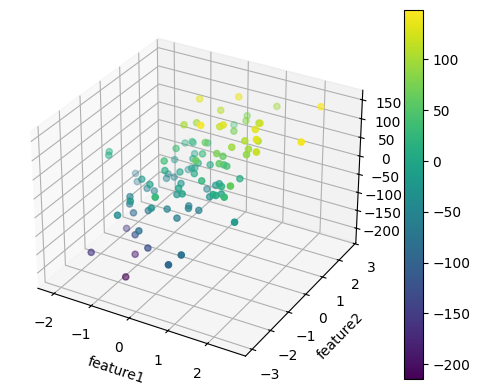

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plt.subplot(111,projection='3d')

scatter = ax.scatter(df['feature1'], df['feature2'], df['target'],
                     c=df['target'])

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('target')

plt.colorbar(scatter)

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train,y_train)

LinearRegression()

In [11]:
y_pred = lr.predict(X_test)

In [12]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 39.14628390757415
MSE 2189.517837564181
R2 score 0.7238786524333811


In [50]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)
# print('x y',xGrid, yGrid)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
# print('final',final)
z_final = lr.predict(final).reshape(10,10)
# print('z_final',z_final)

z = z_final


x y [[-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
   1.66666667  2.77777778  3.88888889  5.        ]
 [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
   1.66666667  2.77777778  3.88888889  5.        ]
 [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
   1.66666667  2.77777778  3.88888889  5.        ]
 [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
   1.66666667  2.77777778  3.88888889  5.        ]
 [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
   1.66666667  2.77777778  3.88888889  5.        ]
 [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
   1.66666667  2.77777778  3.88888889  5.        ]
 [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
   1.66666667  2.77777778  3.88888889  5.        ]
 [-5.         -3.88888889 -2.77777778 -1.66666667 -0.55555556  0.55555556
   1.66666667  2.77777778  3.88888889  5.      

In [42]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [ ]:
lr.coef_

In [ ]:
lr.intercept_

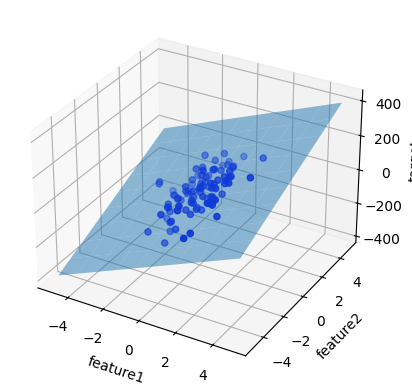

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# create grid
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)

xGrid, yGrid = np.meshgrid(x, y)

# create feature combinations
final = np.c_[xGrid.ravel(), yGrid.ravel()]

# predict plane
z = lr.predict(final).reshape(10,10)

# create figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# scatter points (actual data)
ax.scatter(df['feature1'], df['feature2'], df['target'], color='blue')

# regression plane
ax.plot_surface(xGrid, yGrid, z, alpha=0.5)

# labels
ax.set_xlabel("feature1")
ax.set_ylabel("feature2")
ax.set_zlabel("target")

plt.show()